# Ames Housing Dataset - Feature Engineering

## Objectives

- Handle missing values
- Remove unnecessary features
- Create meaningful features
- Transform skewed variables
- Encode categorical variables
- Prepare data for machine learning

In [501]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [502]:
df = pd.read_csv("/content/train.csv")

In [503]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [504]:
df.shape

(1460, 81)

In [505]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [506]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [507]:
df.duplicated().sum()

np.int64(0)

**Datatype Change**

In [508]:
df.dtypes

,0
Id,int64
MSSubClass,int64
MSZoning,object
LotFrontage,float64
LotArea,int64
...,...
MoSold,int64
YrSold,int64
SaleType,object
SaleCondition,object


In [509]:
df['MSSubClass'].dtype

dtype('int64')

**Null value check**

In [510]:
missing_presentage = ((df.isnull().mean()*100) )

In [511]:
missing_presentage = (missing_presentage[missing_presentage > 0].sort_values(ascending = False))

In [512]:
missing_presentage

,0
PoolQC,99.520548
MiscFeature,96.301370
Alley,93.767123
Fence,80.753425
MasVnrType,59.726027
FireplaceQu,47.260274
LotFrontage,17.739726
GarageType,5.547945
GarageYrBlt,5.547945
GarageFinish,5.547945


## Missing Value Analysis

Columns with missing values were identified before applying imputation strategies.

**Column Droping**

In [513]:
for col in df.columns:
    print(df[col].value_counts(normalize=True).head(1))

Id
1460    0.000685
Name: proportion, dtype: float64
MSSubClass
20    0.367123
Name: proportion, dtype: float64
MSZoning
RL    0.788356
Name: proportion, dtype: float64
LotFrontage
60.0    0.119067
Name: proportion, dtype: float64
LotArea
7200    0.017123
Name: proportion, dtype: float64
Street
Pave    0.99589
Name: proportion, dtype: float64
Alley
Grvl    0.549451
Name: proportion, dtype: float64
LotShape
Reg    0.633562
Name: proportion, dtype: float64
LandContour
Lvl    0.897945
Name: proportion, dtype: float64
Utilities
AllPub    0.999315
Name: proportion, dtype: float64
LotConfig
Inside    0.720548
Name: proportion, dtype: float64
LandSlope
Gtl    0.946575
Name: proportion, dtype: float64
Neighborhood
NAmes    0.15411
Name: proportion, dtype: float64
Condition1
Norm    0.863014
Name: proportion, dtype: float64
Condition2
Norm    0.989726
Name: proportion, dtype: float64
BldgType
1Fam    0.835616
Name: proportion, dtype: float64
HouseStyle
1Story    0.49726
Name: proportion, dtype:

In [514]:
df.drop('Id',axis=1,inplace=True)

In [515]:
df['Utilities'].value_counts()

,count
Utilities,
AllPub,1459
NoSeWa,1


In [516]:
df.drop('Utilities',axis=1,inplace=True)

In [517]:
df['Street'].value_counts()

,count
Street,
Pave,1454
Grvl,6


In [518]:
df.groupby('Street')['SalePrice'].median()

,SalePrice
Street,
Grvl,114250.0
Pave,163000.0


In [519]:
df.drop('Street',axis=1,inplace=True)

In [520]:
df['Heating'].value_counts()

,count
Heating,
GasA,1428
GasW,18
Grav,7
Wall,4
OthW,2
Floor,1


In [521]:
df.groupby('Heating')['SalePrice'].median()

,SalePrice
Heating,
Floor,72500.0
GasA,164500.0
GasW,134950.0
Grav,79000.0
OthW,125750.0
Wall,91450.0


## Feature Removal

- Id removed because it is only an identifier.
- Utilities removed due to near-zero variance.

# **Impute Missing Values**

# Missing Value Handling

Different missing value strategies are applied based on feature meaning.

## Categorical Features

Missing values representing absence of a feature are replaced with:

- None

Examples:

- PoolQC
- FireplaceQu
- Alley
- GarageType

## Numerical Features

Missing values are imputed using median values.

Examples:

- LotFrontage
- MasVnrArea
- GarageYrBlt

In [522]:
none_features = ['PoolQC','Alley','Fence','FireplaceQu','GarageType',
                 'GarageFinish','GarageQual','GarageCond','BsmtQual',
                 'BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2',
                 'MiscFeature','MasVnrType']

In [523]:
for col in none_features:
  df[col].fillna('None',inplace = True)

/tmp/ipykernel_3168/4163952946.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna('None',inplace = True)


In [524]:
df['PoolQC'].head()

,PoolQC
0,None
1,None
2,None
3,None
4,None


In [525]:
missing_presentage = ((df.isnull().mean()*100) )

In [526]:
missing_presentage = (missing_presentage[missing_presentage > 0].sort_values(ascending = False))

In [527]:
missing_presentage

,0
LotFrontage,17.739726
GarageYrBlt,5.547945
MasVnrArea,0.547945
Electrical,0.068493


In [528]:
num_fill_median = [
    'LotFrontage',
    'MasVnrArea',
    'GarageYrBlt'
]

In [529]:
for col in num_fill_median:
    df[col] = df[col].fillna(df[col].median())

In [530]:
df.dropna(inplace = True)

In [531]:
df.isnull().sum().sum()

np.int64(0)

## Missing Value Verification

All missing values have been successfully handled.

# **Binary Feature Indicator**

# Feature Creation

New features are created to capture property characteristics more effectively.

Created Features:

- HasGarage
- HasPool
- HasFireplace
- HasBasement
- TotalSF
- HouseAge
- RemodelAge
- TotalBath
- TotalPorchSF

These features are expected to improve predictive performance by combining related information into more meaningful variables.

In [532]:
df['HasGarage'] = (
    df['GarageArea'] > 0
).astype(int)

In [533]:
df['HasFireplace'] = (
    df['Fireplaces'] > 0
).astype(int)

In [534]:
df['HasPool'] = (
    df['PoolArea'] > 0
).astype(int)

In [535]:
df['HasBasement'] = (
    df['TotalBsmtSF'] > 0
).astype(int)

# **Feature Creation**

In [536]:
df['TotalSF'] = df['1stFlrSF']+df['2ndFlrSF']+df['TotalBsmtSF']

In [537]:
df['TotalSF'].head()

,TotalSF
0,2566
1,2524
2,2706
3,2473
4,3343


In [538]:
df['HouseAge'] = df['YrSold'] - df['YearBuilt']

In [539]:
df['HouseAge'].head()

,HouseAge
0,5
1,31
2,7
3,91
4,8


In [540]:
df['RemodelAge'] = df['YrSold'] - df['YearRemodAdd']

In [541]:
df['RemodelAge'].head()

,RemodelAge
0,5
1,31
2,6
3,36
4,8


In [542]:
df['TotalBath'] = (df['FullBath'] + 0.5 * df['HalfBath'] + df['BsmtFullBath'] + 0.5 * df['BsmtHalfBath'])

In [543]:
df['TotalBath'].head()

,TotalBath
0,3.5
1,2.5
2,3.5
3,2.0
4,3.5


In [544]:
df['TotalPorchSF'] = (df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch'] + df['ScreenPorch'])

In [545]:
df['TotalPorchSF'].head()

,TotalPorchSF
0,61
1,0
2,42
3,307
4,84


# **Log Transformation**

# Feature Transformation

Several numerical features exhibit positive skewness.

Log transformation is applied to selected variables to:

- Reduce skewness
- Stabilize variance
- Improve model performance

In [546]:
num_column = df.select_dtypes(
    include=['int64','float64']
).columns.tolist()

In [547]:
for col in num_column:
  print(f'{col}: {df[col].skew()}')

MSSubClass: 1.4086199979387208
LotFrontage: 2.408664487821274
LotArea: 12.203431161608322
OverallQual: 0.21571915894120147
OverallCond: 0.6920517044846566
YearBuilt: -0.6127634948818556
YearRemodAdd: -0.5026246203453378
MasVnrArea: 2.676550855095343
BsmtFinSF1: 1.685197596255833
BsmtFinSF2: 4.253593525979039
BsmtUnfSF: 0.9193119877192648
TotalBsmtSF: 1.5267604410842321
1stFlrSF: 1.3765042129695153
2ndFlrSF: 0.8143029975016314
LowQualFinSF: 9.00814872059105
GrLivArea: 1.3657010236269942
BsmtFullBath: 0.5949655423583357
BsmtHalfBath: 4.101758736381298
FullBath: 0.03786002507100815
HalfBath: 0.6779718777962563
BedroomAbvGr: 0.21205752732793065
KitchenAbvGr: 4.486640205043308
TotRmsAbvGrd: 0.6767635997783362
Fireplaces: 0.6485802844739271
GarageYrBlt: -0.6777823035684634
GarageCars: -0.3418453857041096
GarageArea: 0.17926563000002016
WoodDeckSF: 1.5409466781423897
OpenPorchSF: 2.363530012193953
EnclosedPorch: 3.088518206617302
3SsnPorch: 10.300724845344117
ScreenPorch: 4.120571559899206
Po

In [548]:
skewness = df[num_column].skew()

skewed_cols = skewness[abs(skewness) > 0.5].index.tolist()

In [549]:
len(skewed_cols)

37

In [550]:
log_transfrom_demo = ['SalePrice','LotFrontage','GrLivArea','TotalSF','MasVnrArea']

In [551]:
for col in log_transfrom_demo:
  df[col+'_log'] = np.log1p(df[col])

In [552]:
for col in log_transfrom_demo:
  print(f'{col+'_log'}: {df[col+'_log'].skew()}')

SalePrice_log: 0.12132931002199303
LotFrontage_log: -0.8692101899395601
GrLivArea_log: -0.006309861148428492
TotalSF_log: -0.3501955548190729
MasVnrArea_log: 0.5023963884795338


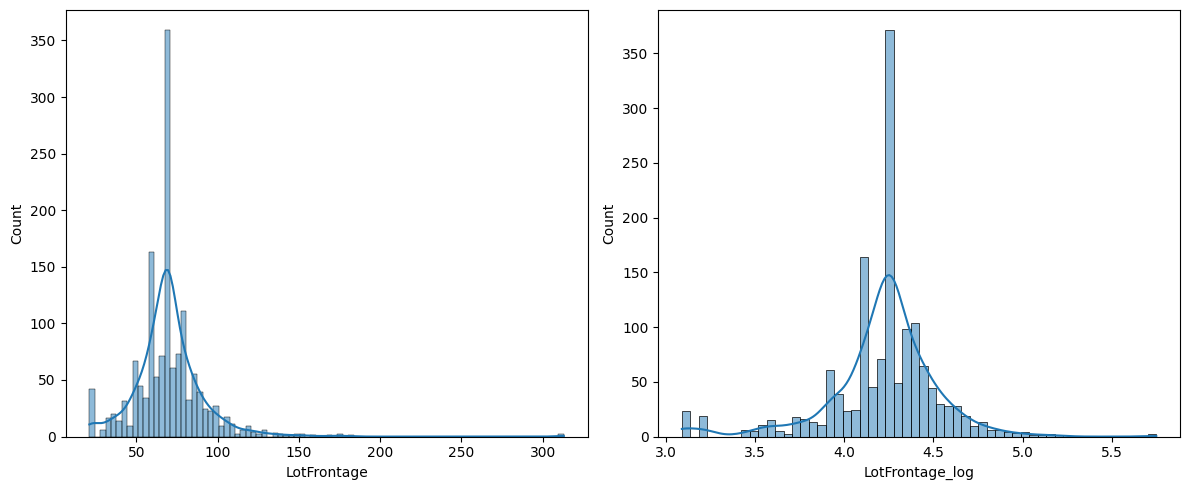

In [553]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(data = df,x = 'LotFrontage',kde = True)

plt.subplot(1,2,2)
sns.histplot(data = df,x = 'LotFrontage_log',kde = True)
plt.tight_layout()
plt.show()

**Standerd scaler**

In [554]:
scaling_deom = ['LotFrontage','SalePrice','TotalSF']

In [555]:
for col in scaling_deom:
  df[col+'_scaled'] = (df[col] - df[col].mean())/df[col].std()

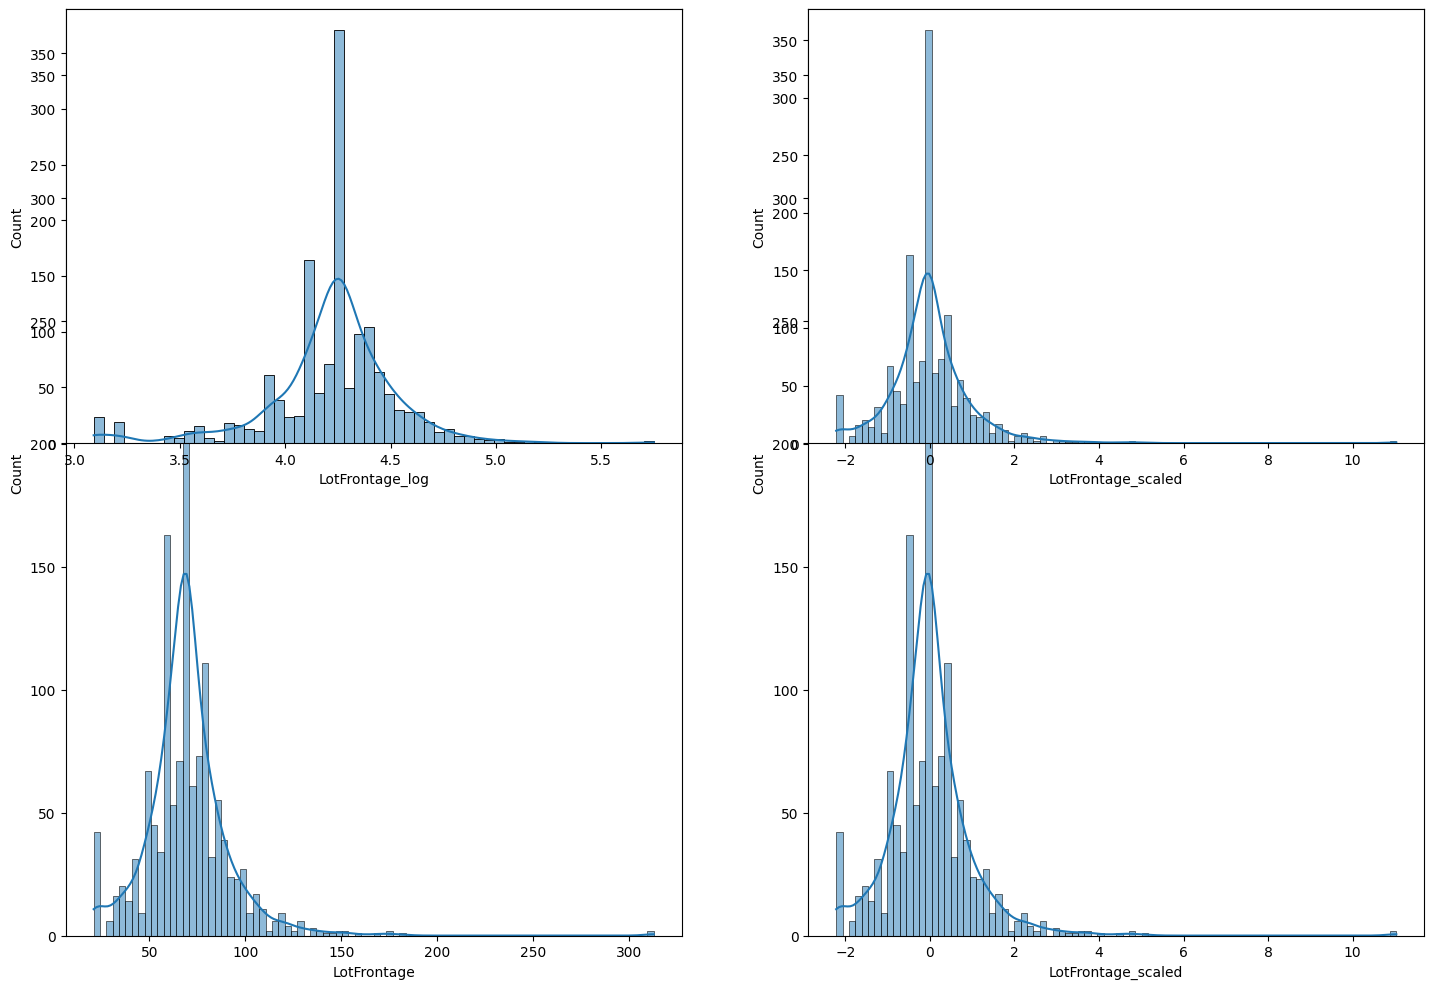

In [556]:
plt.figure(figsize=(15,10))
plt.subplot(1,2,1)
sns.histplot(data = df,x = 'LotFrontage',kde = True)

plt.subplot(1,2,2)
sns.histplot(data = df,x = 'LotFrontage_scaled',kde = True)

plt.subplot(2,2,1)
sns.histplot(data = df,x = 'LotFrontage_log',kde = True)

plt.subplot(2,2,2)
sns.histplot(data = df,x = 'LotFrontage_scaled',kde = True)

plt.tight_layout()
plt.show()

# Scaling Demonstration

Scaling is demonstrated on selected numerical features.

In production workflows, scaling will be handled automatically inside sklearn pipelines.

**Ordinal Encoding**

# Encoding Strategy

Two encoding approaches are used:

## Ordinal Encoding

Applied to ordered quality-related features.

Examples:

- ExterQual
- KitchenQual
- FireplaceQu

## One-Hot Encoding

Applied to nominal categorical variables without natural ordering.

Examples:

- Neighborhood
- GarageType
- SaleCondition

In [557]:
quality_en_cols = ['ExterQual','ExterCond','BsmtQual','BsmtCond','HeatingQC',
                   'KitchenQual','FireplaceQu','GarageQual','GarageCond']

In [558]:
quality_map = {
    'Ex':5,
    'Gd':4,
    'TA':3,
    'Fa':2,
    'Po':1,
    'None':0
}

In [559]:
for col in quality_en_cols:
 df[col] = df[col].map(quality_map)

In [560]:
df['PoolQC'] = df['PoolQC'].map({
    'Ex':4,
    'Gd':3,
    'TA':2,
    'Fa':1,
    'None':0
    })

In [561]:
df['Fence'] = df['Fence'].map({
    'GdPrv':4,
    'MnPrv':3,
    'GdWo':2,
    'MnWw':1,
    'None':0
    })

In [562]:
df['BsmtFinType2'] = df['BsmtFinType2'].map({
    'GLQ':6,
    'ALQ':5,
    'BLQ':4,
    'Rec':3,
    'LwQ':2,
    'Unf':1,
    'None':0
    })

In [563]:
df['BsmtFinType1'] = df['BsmtFinType1'].map({
    'GLQ':6,
    'ALQ':5,
    'BLQ':4,
    'Rec':3,
    'LwQ':2,
    'Unf':1,
    'None':0
    })

In [564]:
df[quality_en_cols].head()

,ExterQual,ExterCond,BsmtQual,BsmtCond,HeatingQC,KitchenQual,FireplaceQu,GarageQual,GarageCond
0,4,3,4,3,5,4,0,3,3
1,3,3,4,3,5,3,3,3,3
2,4,3,4,3,5,4,3,3,3
3,3,3,3,4,4,4,4,3,3
4,4,3,4,3,5,4,3,3,3


**One Hot Encoding**

In [565]:
cat_column = df.select_dtypes(
    include=['object','category']
).columns.tolist()

In [566]:
cat_column

['MSZoning',
 'Alley',
 'LotShape',
 'LandContour',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'Foundation',
 'BsmtExposure',
 'Heating',
 'CentralAir',
 'Electrical',
 'Functional',
 'GarageType',
 'GarageFinish',
 'PavedDrive',
 'MiscFeature',
 'SaleType',
 'SaleCondition']

In [567]:
df.shape

(1459, 95)

In [568]:
df = pd.get_dummies(
    df,
    columns= cat_column,
    drop_first=True
)

In [569]:
df.shape

(1459, 232)

In [570]:
df.sample()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
247,20,75.0,11310,6,5,1954,1954,0.0,3,3,...,False,False,False,False,True,False,False,False,True,False


In [571]:
df.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,4,3,...,False,False,False,False,True,False,False,False,True,False
1,20,80.0,9600,6,8,1976,1976,0.0,3,3,...,False,False,False,False,True,False,False,False,True,False
2,60,68.0,11250,7,5,2001,2002,162.0,4,3,...,False,False,False,False,True,False,False,False,True,False
3,70,60.0,9550,7,5,1915,1970,0.0,3,3,...,False,False,False,False,True,False,False,False,False,False
4,60,84.0,14260,8,5,2000,2000,350.0,4,3,...,False,False,False,False,True,False,False,False,True,False


In [572]:
df.shape

(1459, 232)

In [573]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1459 entries, 0 to 1459
Columns: 232 entries, MSSubClass to SaleCondition_Partial
dtypes: bool(165), float64(12), int64(55)
memory usage: 1010.2 KB


In [574]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
MSSubClass,1459.0,5.688143e+01,42.310746,20.000000,20.000000,50.000000,70.000000,190.000000
LotFrontage,1459.0,6.986155e+01,22.035077,21.000000,60.000000,69.000000,79.000000,313.000000
LotArea,1459.0,1.051736e+04,9984.666267,1300.000000,7549.000000,9477.000000,11603.000000,215245.000000
OverallQual,1459.0,6.100069e+00,1.383171,1.000000,5.000000,6.000000,7.000000,10.000000
OverallCond,1459.0,5.575737e+00,1.113079,1.000000,5.000000,5.000000,6.000000,9.000000
...,...,...,...,...,...,...,...,...
TotalSF_log,1459.0,7.803104e+00,0.313412,5.814131,7.606884,7.814400,8.008033,9.371864
MasVnrArea_log,1459.0,2.121717e+00,2.629074,0.000000,0.000000,0.000000,5.108967,7.378384
LotFrontage_scaled,1459.0,3.189894e-16,1.000000,-2.217444,-0.447539,-0.039099,0.414723,11.034155
SalePrice_scaled,1459.0,3.165543e-17,1.000000,-1.837578,-0.641513,-0.225628,0.416132,7.223821


# Feature Engineering Summary

## Missing Values

- Handled housing-specific missing values
- Median imputation applied where appropriate

## Feature Creation

Created:

- TotalSF
- HouseAge
- RemodelAge
- TotalBath
- TotalPorchSF

## Binary Indicators

Created:

- HasGarage
- HasPool
- HasFireplace
- HasBasement

## Transformations

Applied log transformations to skewed numerical variables.

## Encoding

- Ordinal Encoding for quality-related features
- One-Hot Encoding for nominal categorical variables

The dataset is now ready for machine learning pipeline development.